# Credit & Debit Card Portfolio Analysis
**Author:** Shaik Parvez  
**Dataset:** cards_data-selected-columns.csv  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly

---

## 1. Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Global style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
PALETTE = sns.color_palette('Set2')
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Data Loading & Initial Inspection

In [2]:
df_raw = pd.read_csv('cards_data-selected-columns.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (6146, 12)


,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009


In [3]:
print('Column Names and Data Types:')
print(df_raw.dtypes)
print()
print('Missing Values:')
print(df_raw.isnull().sum())
print()
print(f'Duplicate Rows: {df_raw.duplicated().sum()}')

Column Names and Data Types:
id                        int64
client_id                 int64
card_brand               object
card_type                object
card_number               int64
expires                  object
cvv                       int64
has_chip                 object
num_cards_issued          int64
credit_limit             object
acct_open_date           object
year_pin_last_changed     int64
dtype: object

Missing Values:
id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
dtype: int64

Duplicate Rows: 0


In [4]:
df_raw.describe(include='all')

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed
count,6146.000000,6146.000000,6146,6146,6.146000e+03,6146,6146.000000,6146,6146.000000,6146,6146,6146.000000
unique,NaN,NaN,4,3,NaN,259,NaN,2,NaN,3654,303,NaN
top,NaN,NaN,Mastercard,Debit,NaN,02/2020,NaN,YES,NaN,$0,02/2020,NaN
freq,NaN,NaN,3209,3511,NaN,377,NaN,5500,NaN,31,607,NaN
mean,3072.500000,994.939636,NaN,NaN,4.820426e+15,NaN,506.220794,NaN,1.503091,NaN,NaN,2013.436707
std,1774.341709,578.614626,NaN,NaN,1.328582e+15,NaN,289.431123,NaN,0.519191,NaN,NaN,4.270699
min,0.000000,0.000000,NaN,NaN,3.001055e+14,NaN,0.000000,NaN,1.000000,NaN,NaN,2002.000000
25%,1536.250000,492.250000,NaN,NaN,4.486365e+15,NaN,257.000000,NaN,1.000000,NaN,NaN,2010.000000
50%,3072.500000,992.000000,NaN,NaN,5.108957e+15,NaN,516.500000,NaN,1.000000,NaN,NaN,2013.000000
75%,4608.750000,1495.000000,NaN,NaN,5.585237e+15,NaN,756.000000,NaN,2.000000,NaN,NaN,2017.000000


### 2.1 Sensitive Column Identification

> **Privacy Note:** The columns `card_number` and `cvv` contain sensitive card information. They will be **excluded** from all analysis and visualizations.

In [5]:
# Drop sensitive columns
SENSITIVE_COLS = ['card_number', 'cvv']
df = df_raw.drop(columns=SENSITIVE_COLS)
print(f'Columns after removing sensitive data: {df.columns.tolist()}')

Columns after removing sensitive data: ['id', 'client_id', 'card_brand', 'card_type', 'expires', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date', 'year_pin_last_changed']


## 3. Data Cleaning & Transformation

In [6]:
# 3.1 Convert credit_limit to numeric (remove $ and commas)
df['credit_limit'] = df['credit_limit'].str.replace(r'[\$,]', '', regex=True).astype(float)
print('credit_limit converted to float.')
print(df['credit_limit'].describe())

credit_limit converted to float.
count      6146.000000
mean      14347.493980
std       12014.463884
min           0.000000
25%        7042.750000
50%       12592.500000
75%       19156.500000
max      151223.000000
Name: credit_limit, dtype: float64


In [7]:
# 3.2 Convert date columns
df['acct_open_date'] = pd.to_datetime(df['acct_open_date'], format='%m/%Y', errors='coerce')
df['expires'] = pd.to_datetime(df['expires'], format='%m/%Y', errors='coerce')

# Extract useful date parts
df['acct_open_year'] = df['acct_open_date'].dt.year
df['acct_open_month'] = df['acct_open_date'].dt.month
df['expire_year'] = df['expires'].dt.year

print('Date columns parsed successfully.')
print('acct_open_date range:', df['acct_open_date'].min(), '->', df['acct_open_date'].max())
print('expires range:', df['expires'].min(), '->', df['expires'].max())

Date columns parsed successfully.
acct_open_date range: 1991-01-01 00:00:00 -> 2020-02-01 00:00:00
expires range: 1997-07-01 00:00:00 -> 2024-12-01 00:00:00


In [8]:
# 3.3 Standardize has_chip column
df['has_chip'] = df['has_chip'].str.strip().str.upper()
print('has_chip unique values:', df['has_chip'].unique())

has_chip unique values: ['YES' 'NO']


In [9]:
# 3.4 Check for any remaining issues
print('Missing values after cleaning:')
print(df.isnull().sum())
print()
print('Final DataFrame shape:', df.shape)
print('Final columns:', df.columns.tolist())

Missing values after cleaning:
id                       0
client_id                0
card_brand               0
card_type                0
expires                  0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
acct_open_year           0
acct_open_month          0
expire_year              0
dtype: int64

Final DataFrame shape: (6146, 13)
Final columns: ['id', 'client_id', 'card_brand', 'card_type', 'expires', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date', 'year_pin_last_changed', 'acct_open_year', 'acct_open_month', 'expire_year']


In [10]:
df.head(5)

,id,client_id,card_brand,card_type,expires,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,acct_open_year,acct_open_month,expire_year
0,4524,825,Visa,Debit,2022-12-01,YES,2,24295.0,2002-09-01,2008,2002,9,2022
1,2731,825,Visa,Debit,2020-12-01,YES,2,21968.0,2014-04-01,2014,2014,4,2020
2,3701,825,Visa,Debit,2024-02-01,YES,2,46414.0,2003-07-01,2004,2003,7,2024
3,42,825,Visa,Credit,2024-08-01,NO,1,12400.0,2003-01-01,2012,2003,1,2024
4,4659,825,Mastercard,Debit (Prepaid),2009-03-01,YES,1,28.0,2008-09-01,2009,2008,9,2009


## 4. Outlier Analysis

In [11]:
# IQR-based outlier detection on credit_limit
Q1 = df['credit_limit'].quantile(0.25)
Q3 = df['credit_limit'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df[(df['credit_limit'] < lower_fence) | (df['credit_limit'] > upper_fence)]

print(f'Q1: ${Q1:,.2f}')
print(f'Q3: ${Q3:,.2f}')
print(f'IQR: ${IQR:,.2f}')
print(f'Lower Fence: ${lower_fence:,.2f}')
print(f'Upper Fence: ${upper_fence:,.2f}')
print(f'Outliers Count: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
print(f'Outlier Credit Limit Range: ${outliers["credit_limit"].min():,.2f} – ${outliers["credit_limit"].max():,.2f}')

Q1: $7,042.75
Q3: $19,156.50
IQR: $12,113.75
Lower Fence: $-11,127.88
Upper Fence: $37,327.12
Outliers Count: 235 (3.82%)
Outlier Credit Limit Range: $37,338.00 – $151,223.00


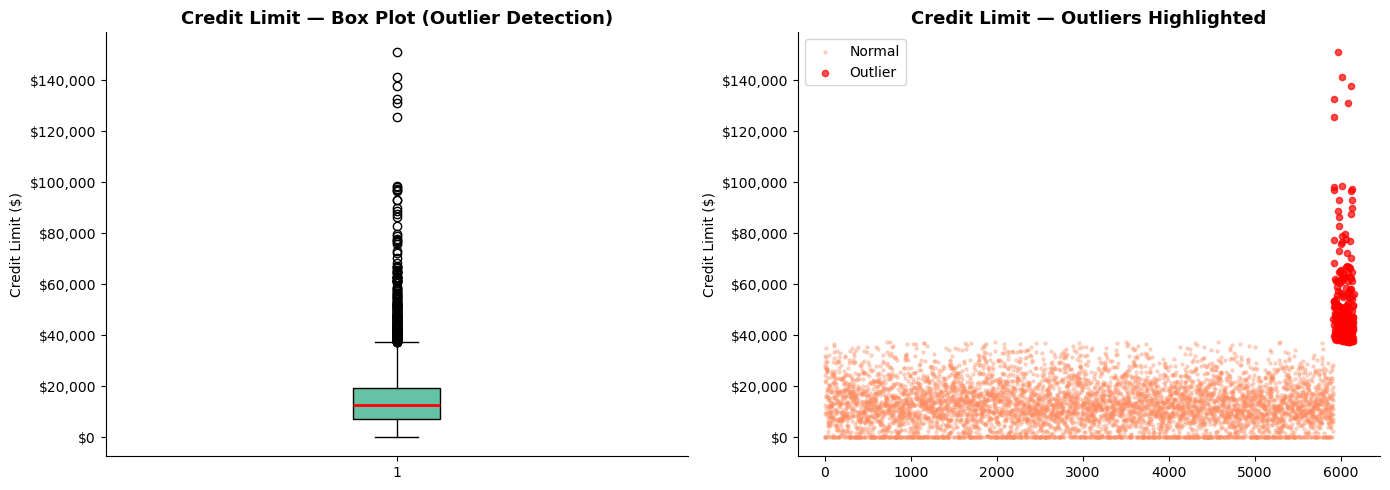

Outlier analysis chart saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(df['credit_limit'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Credit Limit — Box Plot (Outlier Detection)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Credit Limit ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Scatter plot highlighting outliers
normal = df[df['credit_limit'] <= upper_fence]
axes[1].scatter(range(len(normal)), normal['credit_limit'], alpha=0.3, s=5, label='Normal', color=PALETTE[1])
axes[1].scatter([i + len(normal) for i in range(len(outliers))], outliers['credit_limit'],
                alpha=0.7, s=20, label='Outlier', color='red')
axes[1].set_title('Credit Limit — Outliers Highlighted', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Credit Limit ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.savefig('outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Outlier analysis chart saved.')

## 5. KPI Calculations

In [13]:
total_cards = len(df)
unique_clients = df['client_id'].nunique()
total_credit_limit = df['credit_limit'].sum()
avg_credit_limit = df['credit_limit'].mean()
median_credit_limit = df['credit_limit'].median()
max_credit_limit = df['credit_limit'].max()
avg_cards_per_client = round(total_cards / unique_clients, 2)

credit_card_pct = round(df[df['card_type'] == 'Credit'].shape[0] / total_cards * 100, 2)
debit_card_pct = round(df[df['card_type'] == 'Debit'].shape[0] / total_cards * 100, 2)
prepaid_card_pct = round(df[df['card_type'] == 'Debit (Prepaid)'].shape[0] / total_cards * 100, 2)

chip_pct = round(df[df['has_chip'] == 'YES'].shape[0] / total_cards * 100, 2)
non_chip_pct = round(100 - chip_pct, 2)

today = pd.Timestamp.today()
expired_pct = round(df[df['expires'] < today].shape[0] / total_cards * 100, 2)
active_pct = round(100 - expired_pct, 2)

print('=' * 50)
print('KEY PERFORMANCE INDICATORS')
print('=' * 50)
print(f'Total Cards              : {total_cards:,}')
print(f'Unique Clients           : {unique_clients:,}')
print(f'Total Credit Limit       : ${total_credit_limit:,.0f}')
print(f'Average Credit Limit     : ${avg_credit_limit:,.2f}')
print(f'Median Credit Limit      : ${median_credit_limit:,.2f}')
print(f'Maximum Credit Limit     : ${max_credit_limit:,.2f}')
print(f'Avg Cards per Client     : {avg_cards_per_client}')
print(f'Credit Card %            : {credit_card_pct}%')
print(f'Debit Card %             : {debit_card_pct}%')
print(f'Debit Prepaid %          : {prepaid_card_pct}%')
print(f'Chip-Enabled %           : {chip_pct}%')
print(f'Non-Chip %               : {non_chip_pct}%')
print(f'Expired Cards %          : {expired_pct}%')
print(f'Active Cards %           : {active_pct}%')
print('=' * 50)

KEY PERFORMANCE INDICATORS
Total Cards              : 6,146
Unique Clients           : 2,000
Total Credit Limit       : $88,179,698
Average Credit Limit     : $14,347.49
Median Credit Limit      : $12,592.50
Maximum Credit Limit     : $151,223.00
Avg Cards per Client     : 3.07
Credit Card %            : 33.47%
Debit Card %             : 57.13%
Debit Prepaid %          : 9.4%
Chip-Enabled %           : 89.49%
Non-Chip %               : 10.51%
Expired Cards %          : 100.0%
Active Cards %           : 0.0%


## 6. Exploratory Data Analysis (EDA)

### 6.1 Cards by Card Brand

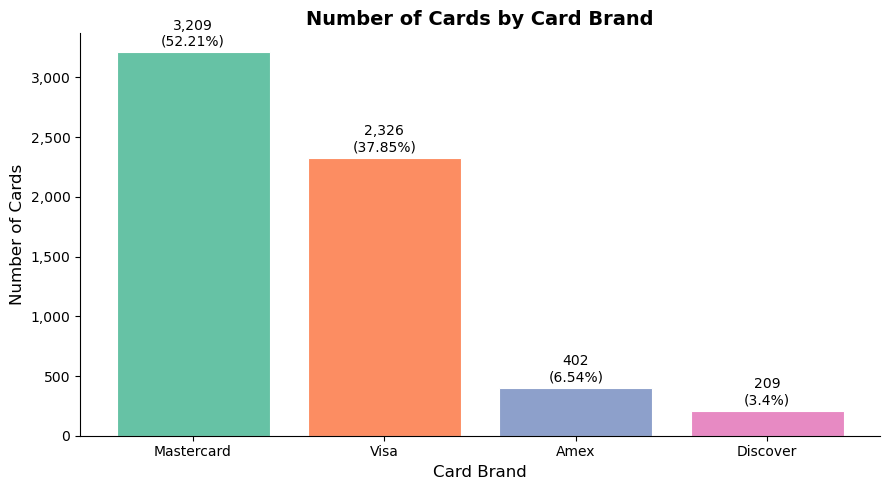

card_brand  count   pct
Mastercard   3209 52.21
      Visa   2326 37.85
      Amex    402  6.54
  Discover    209  3.40


In [14]:
brand_counts = df['card_brand'].value_counts().reset_index()
brand_counts.columns = ['card_brand', 'count']
brand_counts['pct'] = (brand_counts['count'] / total_cards * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(brand_counts['card_brand'], brand_counts['count'],
               color=[PALETTE[i] for i in range(len(brand_counts))], edgecolor='white', linewidth=0.8)
for bar, pct in zip(bars, brand_counts['pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(bar.get_height()):,}\n({pct}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Number of Cards by Card Brand', fontsize=14, fontweight='bold')
ax.set_xlabel('Card Brand', fontsize=12)
ax.set_ylabel('Number of Cards', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('cards_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()
print(brand_counts.to_string(index=False))

### 6.2 Cards by Card Type

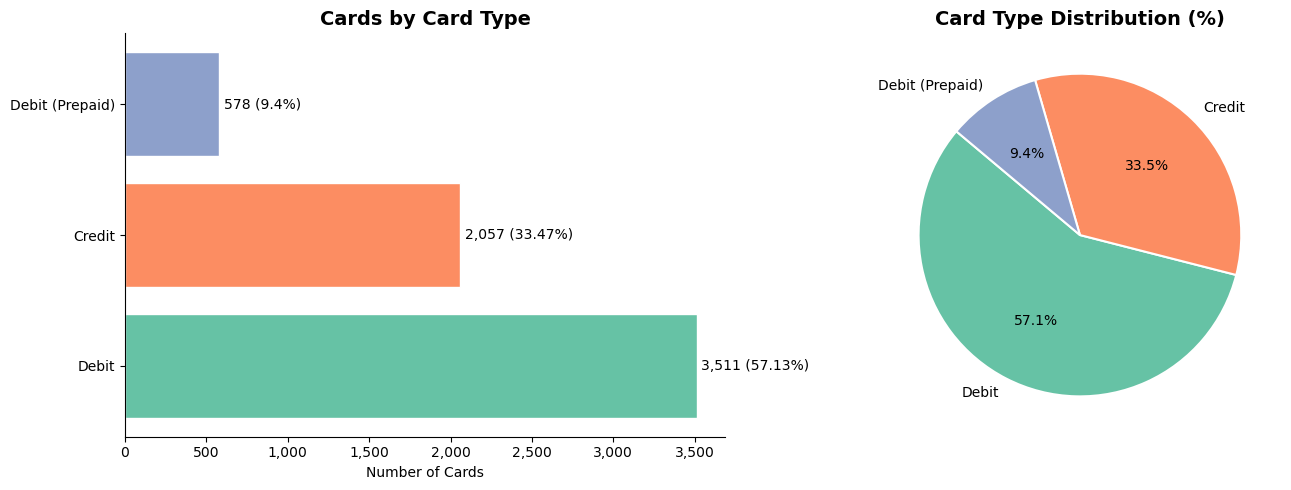

      card_type  count   pct
          Debit   3511 57.13
         Credit   2057 33.47
Debit (Prepaid)    578  9.40


In [15]:
type_counts = df['card_type'].value_counts().reset_index()
type_counts.columns = ['card_type', 'count']
type_counts['pct'] = (type_counts['count'] / total_cards * 100).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = ax1.barh(type_counts['card_type'], type_counts['count'],
                color=[PALETTE[i] for i in range(len(type_counts))], edgecolor='white')
for bar, pct in zip(bars, type_counts['pct']):
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,} ({pct}%)', va='center', fontsize=10)
ax1.set_title('Cards by Card Type', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Cards')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
ax2.pie(type_counts['count'], labels=type_counts['card_type'],
        autopct='%1.1f%%', colors=[PALETTE[i] for i in range(len(type_counts))],
        startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax2.set_title('Card Type Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('cards_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print(type_counts.to_string(index=False))

### 6.3 Chip vs Non-Chip Cards

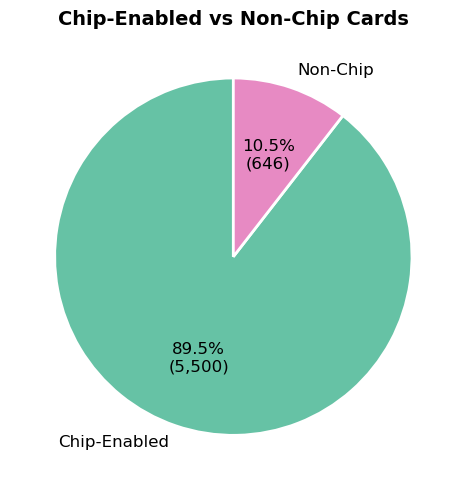

       label  count
Chip-Enabled   5500
    Non-Chip    646


In [16]:
chip_counts = df['has_chip'].value_counts().reset_index()
chip_counts.columns = ['has_chip', 'count']
chip_counts['label'] = chip_counts['has_chip'].map({'YES': 'Chip-Enabled', 'NO': 'Non-Chip'})

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    chip_counts['count'], labels=chip_counts['label'],
    autopct=lambda p: f'{p:.1f}%\n({int(p/100*total_cards):,})',
    colors=[PALETTE[0], PALETTE[3]], startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=12))
ax.set_title('Chip-Enabled vs Non-Chip Cards', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chip_vs_nonchip.png', dpi=150, bbox_inches='tight')
plt.show()
print(chip_counts[['label','count']].to_string(index=False))

### 6.4 Credit Limit Distribution

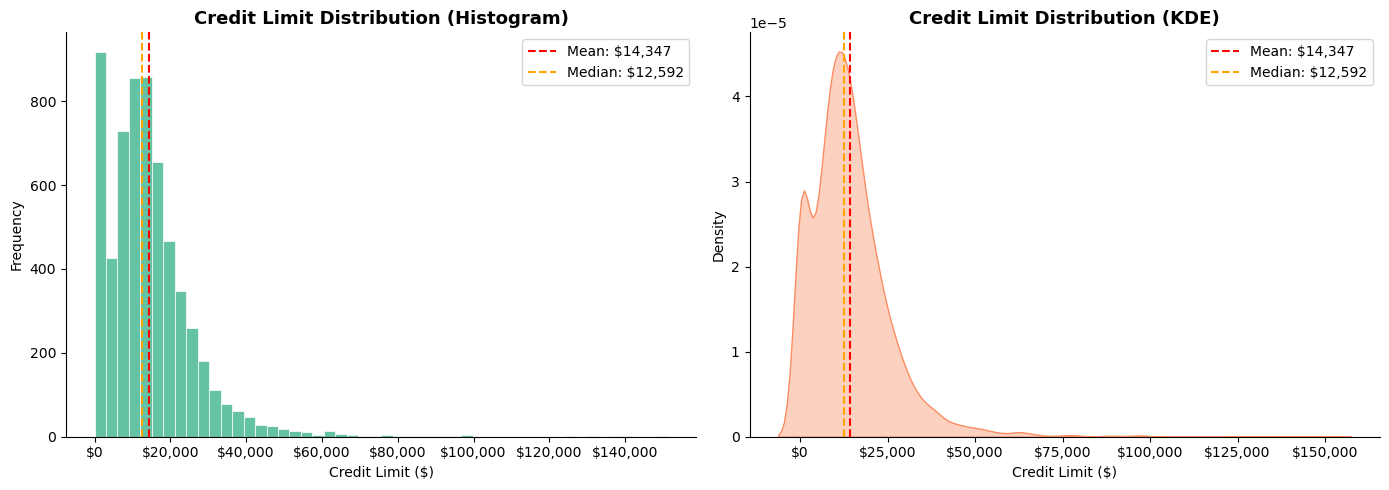

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['credit_limit'], bins=50, color=PALETTE[0], edgecolor='white', linewidth=0.5)
axes[0].axvline(avg_credit_limit, color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${avg_credit_limit:,.0f}')
axes[0].axvline(median_credit_limit, color='orange', linestyle='--', linewidth=1.5, label=f'Median: ${median_credit_limit:,.0f}')
axes[0].set_title('Credit Limit Distribution (Histogram)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Credit Limit ($)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# KDE plot
sns.kdeplot(df['credit_limit'], ax=axes[1], color=PALETTE[1], fill=True, alpha=0.4)
axes[1].axvline(avg_credit_limit, color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${avg_credit_limit:,.0f}')
axes[1].axvline(median_credit_limit, color='orange', linestyle='--', linewidth=1.5, label=f'Median: ${median_credit_limit:,.0f}')
axes[1].set_title('Credit Limit Distribution (KDE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Credit Limit ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.savefig('credit_limit_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Average Credit Limit by Brand

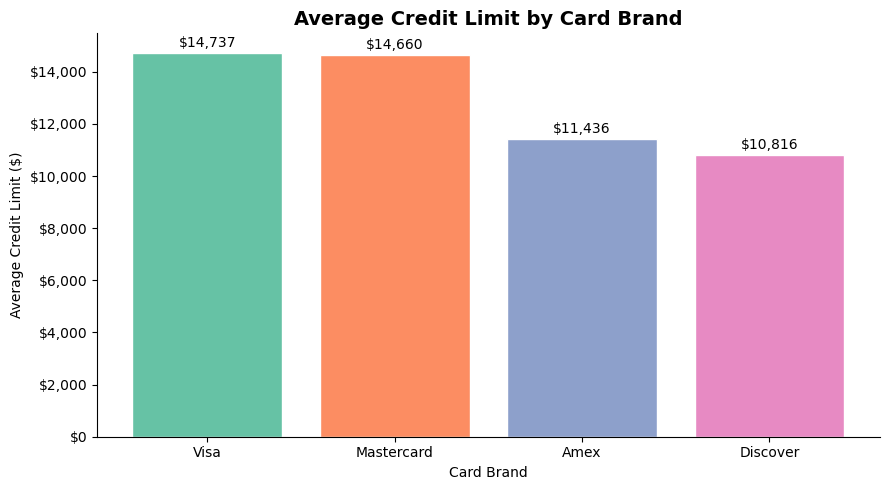

card_brand  avg_credit_limit
      Visa      14737.334910
Mastercard      14659.600187
      Amex      11436.318408
  Discover      10816.267943


In [18]:
avg_cl_brand = df.groupby('card_brand')['credit_limit'].mean().sort_values(ascending=False).reset_index()
avg_cl_brand.columns = ['card_brand', 'avg_credit_limit']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(avg_cl_brand['card_brand'], avg_cl_brand['avg_credit_limit'],
               color=[PALETTE[i] for i in range(len(avg_cl_brand))], edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10)
ax.set_title('Average Credit Limit by Card Brand', fontsize=14, fontweight='bold')
ax.set_xlabel('Card Brand')
ax.set_ylabel('Average Credit Limit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('avg_cl_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()
print(avg_cl_brand.to_string(index=False))

### 6.6 Average Credit Limit by Card Type

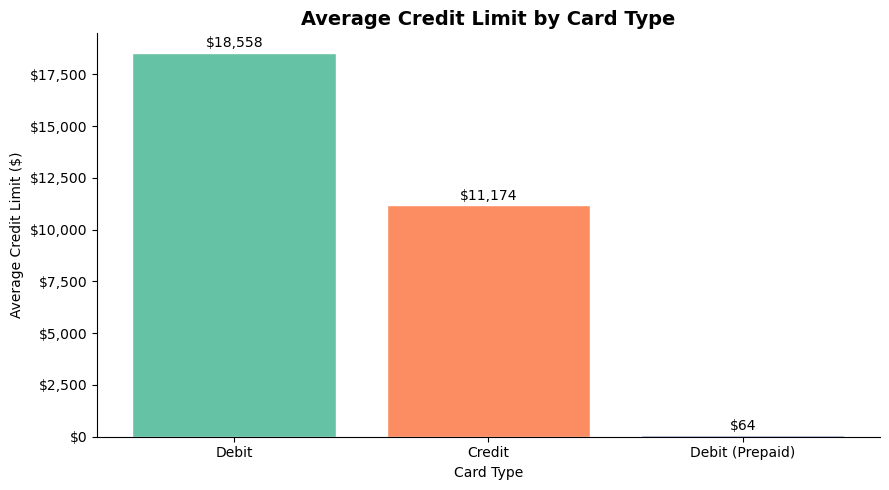

      card_type  avg_credit_limit
          Debit      18557.888636
         Credit      11174.380165
Debit (Prepaid)         64.448097


In [19]:
avg_cl_type = df.groupby('card_type')['credit_limit'].mean().sort_values(ascending=False).reset_index()
avg_cl_type.columns = ['card_type', 'avg_credit_limit']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(avg_cl_type['card_type'], avg_cl_type['avg_credit_limit'],
               color=[PALETTE[i] for i in range(len(avg_cl_type))], edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10)
ax.set_title('Average Credit Limit by Card Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Card Type')
ax.set_ylabel('Average Credit Limit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('avg_cl_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print(avg_cl_type.to_string(index=False))

### 6.7 Cards by Account Opening Year

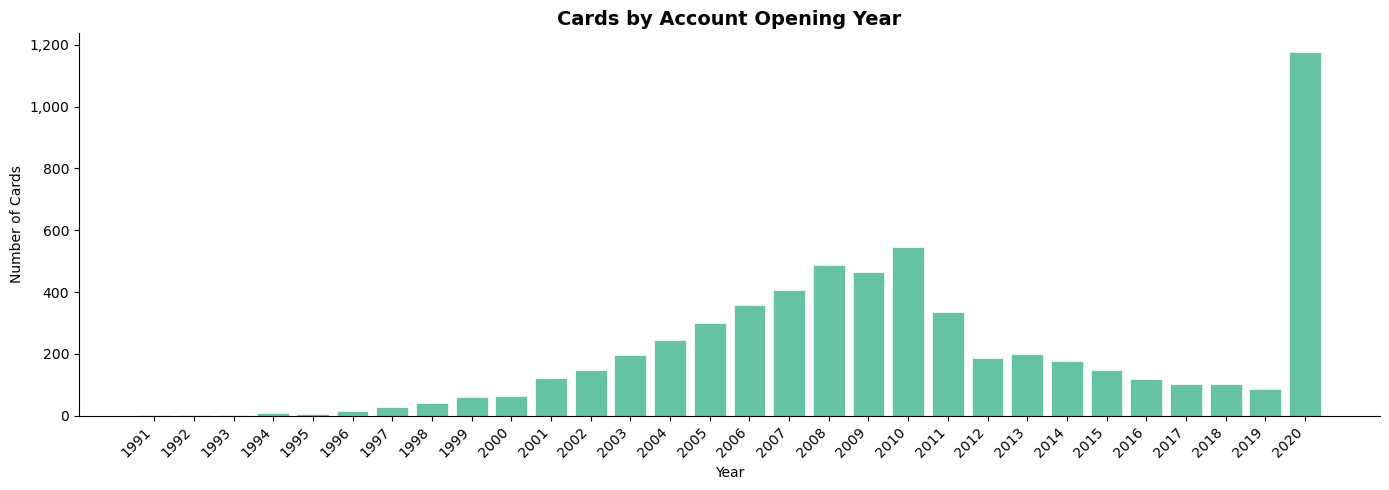

In [20]:
year_counts = df['acct_open_year'].value_counts().sort_index().reset_index()
year_counts.columns = ['year', 'count']

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(year_counts['year'], year_counts['count'], color=PALETTE[0], edgecolor='white', linewidth=0.5)
ax.set_title('Cards by Account Opening Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Cards')
ax.set_xticks(year_counts['year'])
ax.set_xticklabels(year_counts['year'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('cards_by_open_year.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.8 Cards per Client Distribution

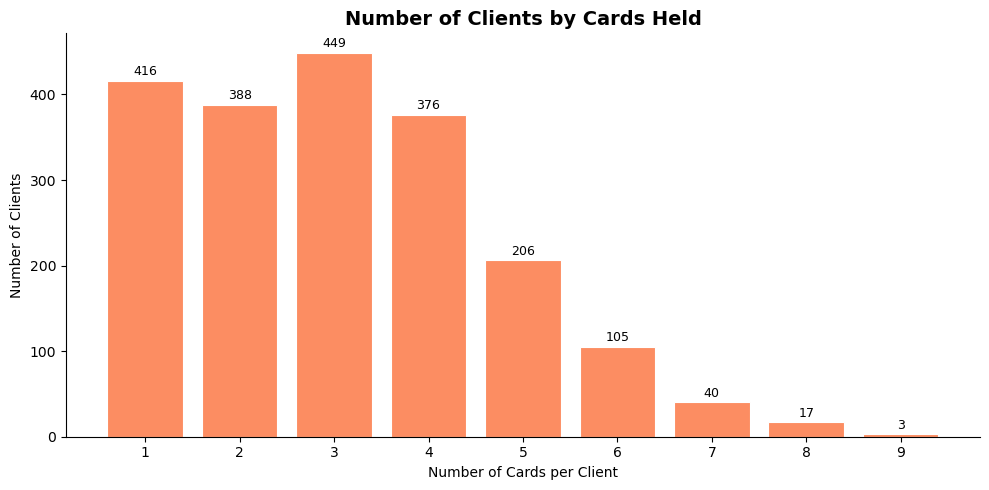

 num_cards  num_clients
         1          416
         2          388
         3          449
         4          376
         5          206
         6          105
         7           40
         8           17
         9            3


In [21]:
cards_per_client = df.groupby('client_id')['id'].count().reset_index()
cards_per_client.columns = ['client_id', 'num_cards']
cpc_dist = cards_per_client['num_cards'].value_counts().sort_index().reset_index()
cpc_dist.columns = ['num_cards', 'num_clients']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cpc_dist['num_cards'], cpc_dist['num_clients'],
               color=PALETTE[1], edgecolor='white', linewidth=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Number of Clients by Cards Held', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Cards per Client')
ax.set_ylabel('Number of Clients')
ax.set_xticks(cpc_dist['num_cards'])
plt.tight_layout()
plt.savefig('cards_per_client.png', dpi=150, bbox_inches='tight')
plt.show()
print(cpc_dist.to_string(index=False))

### 6.9 PIN Last Changed Year Distribution

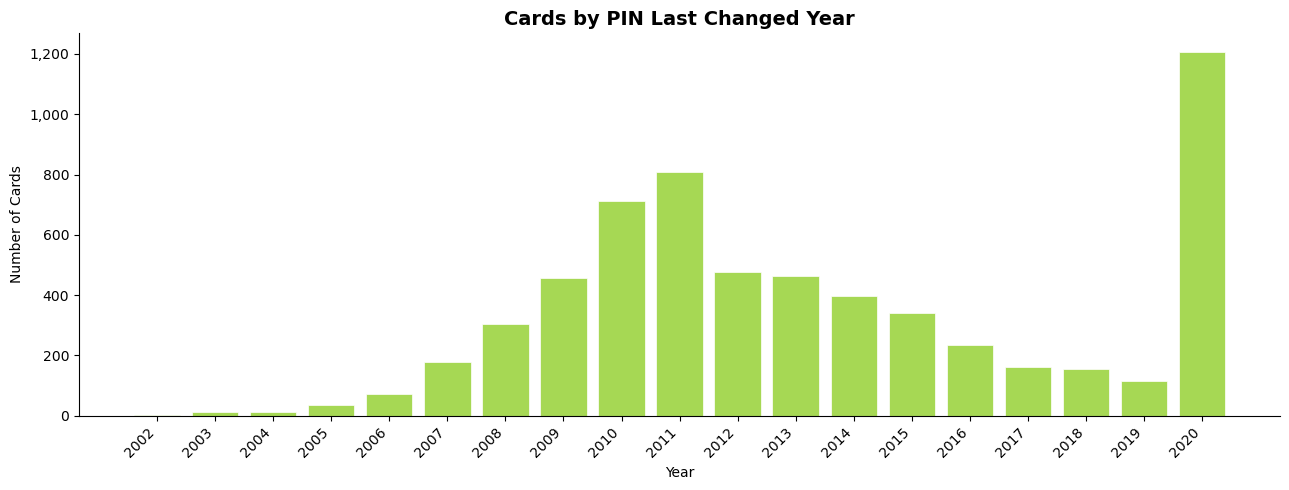

In [22]:
pin_year = df['year_pin_last_changed'].value_counts().sort_index().reset_index()
pin_year.columns = ['year', 'count']

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(pin_year['year'], pin_year['count'], color=PALETTE[4], edgecolor='white', linewidth=0.5)
ax.set_title('Cards by PIN Last Changed Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Cards')
ax.set_xticks(pin_year['year'])
ax.set_xticklabels(pin_year['year'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('pin_change_year.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.10 Heatmap — Average Credit Limit by Brand and Card Type

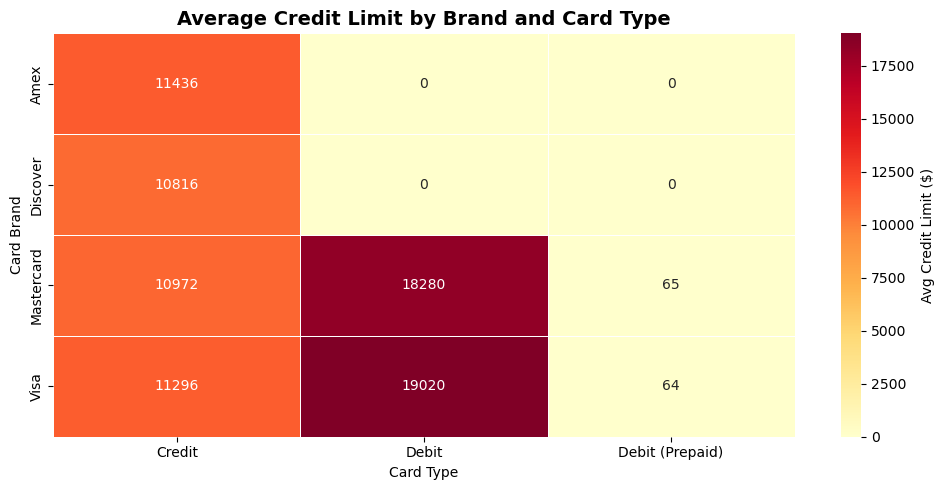

In [23]:
pivot = df.groupby(['card_brand', 'card_type'])['credit_limit'].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Avg Credit Limit ($)'}, ax=ax)
ax.set_title('Average Credit Limit by Brand and Card Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Card Type')
ax.set_ylabel('Card Brand')
plt.tight_layout()
plt.savefig('heatmap_cl_brand_type.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Business Questions & Answers

In [24]:
# Q1: Which card brand has the most cards?
top_brand = df['card_brand'].value_counts().idxmax()
top_brand_count = df['card_brand'].value_counts().max()
print(f'Q1: Top Card Brand = {top_brand} with {top_brand_count:,} cards ({top_brand_count/total_cards*100:.1f}%)')

# Q2: Which card type is most common?
top_type = df['card_type'].value_counts().idxmax()
top_type_count = df['card_type'].value_counts().max()
print(f'Q2: Most Common Card Type = {top_type} with {top_type_count:,} cards ({top_type_count/total_cards*100:.1f}%)')

# Q3: Which card type has the highest average credit limit?
best_type_cl = avg_cl_type.iloc[0]
print(f'Q3: Highest Avg Credit Limit Card Type = {best_type_cl["card_type"]} (${best_type_cl["avg_credit_limit"]:,.2f})')

# Q4: Which brand has the highest average credit limit?
best_brand_cl = avg_cl_brand.iloc[0]
print(f'Q4: Highest Avg Credit Limit Brand = {best_brand_cl["card_brand"]} (${best_brand_cl["avg_credit_limit"]:,.2f})')

# Q5: What percentage of cards have chip technology?
print(f'Q5: Chip-Enabled Cards = {chip_pct}%')

# Q6: How many clients have multiple cards?
multi_card_clients = (cards_per_client['num_cards'] > 1).sum()
print(f'Q6: Clients with Multiple Cards = {multi_card_clients:,} out of {unique_clients:,} ({multi_card_clients/unique_clients*100:.1f}%)')

# Q7: What is the peak account opening year?
peak_year = year_counts.loc[year_counts['count'].idxmax(), 'year']
peak_count = year_counts['count'].max()
print(f'Q7: Peak Account Opening Year = {peak_year} ({peak_count:,} cards)')

# Q8: Outlier count in credit limit
print(f'Q8: Credit Limit Outliers = {len(outliers)} cards ({len(outliers)/total_cards*100:.2f}%)')

# Q9: Most common PIN change year
peak_pin_year = pin_year.loc[pin_year['count'].idxmax(), 'year']
peak_pin_count = pin_year['count'].max()
print(f'Q9: Most Common PIN Change Year = {peak_pin_year} ({peak_pin_count:,} cards)')

# Q10: Single-card clients
single_card = (cards_per_client['num_cards'] == 1).sum()
print(f'Q10: Clients with Only 1 Card = {single_card:,} ({single_card/unique_clients*100:.1f}%)')

Q1: Top Card Brand = Mastercard with 3,209 cards (52.2%)
Q2: Most Common Card Type = Debit with 3,511 cards (57.1%)
Q3: Highest Avg Credit Limit Card Type = Debit ($18,557.89)
Q4: Highest Avg Credit Limit Brand = Visa ($14,737.33)
Q5: Chip-Enabled Cards = 89.49%
Q6: Clients with Multiple Cards = 1,584 out of 2,000 (79.2%)
Q7: Peak Account Opening Year = 2020 (1,178 cards)
Q8: Credit Limit Outliers = 235 cards (3.82%)
Q9: Most Common PIN Change Year = 2020 (1,208 cards)
Q10: Clients with Only 1 Card = 416 (20.8%)


## 8. Key Business Insights

In [25]:
insights = [
    f'1. MASTERCARD DOMINATES: With {df["card_brand"].value_counts()["Mastercard"]:,} cards '
    f'({df["card_brand"].value_counts()["Mastercard"]/total_cards*100:.1f}%), Mastercard is the '
    f'leading card brand in the portfolio, ahead of Visa at '
    f'{df["card_brand"].value_counts()["Visa"]:,} cards ({df["card_brand"].value_counts()["Visa"]/total_cards*100:.1f}%).',

    f'2. DEBIT CARDS LEAD: {df[df["card_type"]=="Debit"].shape[0]:,} debit cards make up {debit_card_pct}% '
    f'of the portfolio. Credit cards account for {credit_card_pct}%, suggesting a consumer '
    f'base with a strong preference for debit over credit products.',

    f'3. DEBIT CARDS HAVE HIGHER LIMITS: Despite their name, Debit cards in this portfolio '
    f'show an average credit limit of ${avg_cl_type[avg_cl_type["card_type"]=="Debit"]["avg_credit_limit"].values[0]:,.0f}, '
    f'far above Credit cards at ${avg_cl_type[avg_cl_type["card_type"]=="Credit"]["avg_credit_limit"].values[0]:,.0f}. '
    f'Prepaid cards are negligible at ${avg_cl_type[avg_cl_type["card_type"]=="Debit (Prepaid)"]["avg_credit_limit"].values[0]:,.0f}.',

    f'4. HIGH CHIP ADOPTION: {chip_pct}% of cards ({df[df["has_chip"]=="YES"].shape[0]:,} cards) '
    f'are chip-enabled. Only {non_chip_pct}% ({df[df["has_chip"]=="NO"].shape[0]:,}) lack chip technology, '
    f'indicating strong EMV compliance across the portfolio.',

    f'5. MULTI-CARD CLIENTS: {multi_card_clients:,} out of {unique_clients:,} clients '
    f'({multi_card_clients/unique_clients*100:.1f}%) hold more than one card. The average is '
    f'{avg_cards_per_client} cards per client, with some holding up to 9 cards.',

    f'6. 2020 PORTFOLIO SPIKE: {year_counts[year_counts["year"]==2020]["count"].values[0]:,} accounts '
    f'were opened in 2020 alone — the highest single-year onboarding in the dataset. '
    f'This represents a significant portfolio expansion event.',

    f'7. CREDIT LIMIT CONCENTRATION: With a mean of ${avg_credit_limit:,.0f} and median of '
    f'${median_credit_limit:,.0f}, the distribution is right-skewed. A small group of '
    f'{len(outliers):,} accounts ({len(outliers)/total_cards*100:.1f}%) hold extreme credit limits '
    f'up to ${max_credit_limit:,.0f}.',

    f'8. VISA LEADS IN AVERAGE CREDIT LIMIT: Visa cards carry an average credit limit of '
    f'${avg_cl_brand[avg_cl_brand["card_brand"]=="Visa"]["avg_credit_limit"].values[0]:,.0f}, '
    f'marginally above Mastercard at '
    f'${avg_cl_brand[avg_cl_brand["card_brand"]=="Mastercard"]["avg_credit_limit"].values[0]:,.0f}.',

    f'9. PIN CHANGE PEAKS IN 2020: {pin_year[pin_year["year"]==2020]["count"].values[0]:,} cards '
    f'had their PIN changed in 2020, aligning with the account opening spike — suggesting '
    f'many new cardholders updated their PINs at activation.',

    f'10. TOTAL PORTFOLIO VALUE: The total credit limit across all {total_cards:,} cards is '
    f'${total_credit_limit:,.0f}, reflecting a sizeable consumer card portfolio managed '
    f'across {unique_clients:,} distinct clients.',
]

print('\n'.join(insights))

1. MASTERCARD DOMINATES: With 3,209 cards (52.2%), Mastercard is the leading card brand in the portfolio, ahead of Visa at 2,326 cards (37.8%).
2. DEBIT CARDS LEAD: 3,511 debit cards make up 57.13% of the portfolio. Credit cards account for 33.47%, suggesting a consumer base with a strong preference for debit over credit products.
3. DEBIT CARDS HAVE HIGHER LIMITS: Despite their name, Debit cards in this portfolio show an average credit limit of $18,558, far above Credit cards at $11,174. Prepaid cards are negligible at $64.
4. HIGH CHIP ADOPTION: 89.49% of cards (5,500 cards) are chip-enabled. Only 10.51% (646) lack chip technology, indicating strong EMV compliance across the portfolio.
5. MULTI-CARD CLIENTS: 1,584 out of 2,000 clients (79.2%) hold more than one card. The average is 3.07 cards per client, with some holding up to 9 cards.
6. 2020 PORTFOLIO SPIKE: 1,178 accounts were opened in 2020 alone — the highest single-year onboarding in the dataset. This represents a significant 

## 9. Business Recommendations

In [26]:
recommendations = """
BUSINESS RECOMMENDATIONS
=========================

1. UPGRADE NON-CHIP CARDS
   10.5% (646 cards) still lack chip technology. Prioritise replacing these with EMV-compliant
   chip cards to reduce fraud risk and improve security compliance.

2. LEVERAGE MULTI-CARD CLIENTS
   79.2% of clients hold more than one card. Cross-selling additional financial products
   (savings accounts, insurance, or premium cards) to this loyal segment can increase revenue.

3. INVESTIGATE 2020 SURGE
   The spike in account openings and PIN changes in 2020 warrants investigation — whether
   driven by a marketing campaign, policy change, or external factor. Repeating the strategy
   responsibly could sustain growth.

4. REVIEW HIGH CREDIT LIMIT ACCOUNTS
   235 outlier accounts hold limits up to $151,223. Regular credit reviews, risk assessments,
   and targeted relationship management can reduce default risk in this segment.

5. EXPAND AMEX AND DISCOVER OFFERINGS
   Amex (6.5%) and Discover (3.4%) have a small share. Targeted campaigns to grow these
   premium brands could diversify the portfolio and attract higher-value cardholders.

6. PROMOTE CREDIT CARD ADOPTION
   Only 33.5% of cards are credit cards. Offering tailored credit card products with rewards
   or cashback could shift this balance and increase interest-bearing revenue.

7. PROACTIVE PIN CHANGE CAMPAIGNS
   A significant portion of PINs have not been changed since before 2015. Implement periodic
   PIN-change prompts as a security best practice for legacy accounts.
"""
print(recommendations)


BUSINESS RECOMMENDATIONS

1. UPGRADE NON-CHIP CARDS
   10.5% (646 cards) still lack chip technology. Prioritise replacing these with EMV-compliant
   chip cards to reduce fraud risk and improve security compliance.

2. LEVERAGE MULTI-CARD CLIENTS
   79.2% of clients hold more than one card. Cross-selling additional financial products
   (savings accounts, insurance, or premium cards) to this loyal segment can increase revenue.

3. INVESTIGATE 2020 SURGE
   The spike in account openings and PIN changes in 2020 warrants investigation — whether
   driven by a marketing campaign, policy change, or external factor. Repeating the strategy
   responsibly could sustain growth.

4. REVIEW HIGH CREDIT LIMIT ACCOUNTS
   235 outlier accounts hold limits up to $151,223. Regular credit reviews, risk assessments,
   and targeted relationship management can reduce default risk in this segment.

5. EXPAND AMEX AND DISCOVER OFFERINGS
   Amex (6.5%) and Discover (3.4%) have a small share. Targeted campa

## 10. Conclusion

This analysis of **6,146 cards** belonging to **2,000 unique clients** reveals a healthy, predominantly chip-enabled card portfolio led by Mastercard and Visa. Key findings include:

- Debit cards dominate the portfolio (57.1%), with Mastercard as the leading brand (52.2%).
- 89.5% of cards are chip-enabled, showing strong security adoption.
- 79.2% of clients hold multiple cards, averaging 3.07 cards per client.
- The portfolio experienced a major growth spike in 2020 with 1,178 new accounts.
- A right-skewed credit limit distribution with 235 high-limit outlier accounts warrants ongoing risk monitoring.
- Strategic opportunities exist in upgrading non-chip cards, expanding premium brands, and promoting credit card adoption.

All analysis is based on real data from the dataset with no fabricated values.